In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statistics as st

In [ ]:
cont, disc = "peso (kg)", "idade (anos)"

mu, sigma = 5, 2 # mean and standard deviation
df = pd.DataFrame({
        cont: np.random.normal(mu, sigma, 1_000),
        disc: np.random.normal(mu, sigma, 1_000) // 1
    },
).round(2).reset_index()
df.head()

,index,peso (kg),idade (anos)
0,0,4.92,3.0
1,1,6.73,3.0
2,2,5.82,6.0
3,3,8.73,6.0
4,4,7.20,2.0


In [10]:
df_sample = df.sample(5)
df_sample[cont]

718    4.12
296    1.11
459    4.39
541    0.50
942    7.43
Name: peso (kg), dtype: float64

In [11]:
df_sample_mean = df_sample[cont].rolling(window=2).mean()
df_sample_mean.iloc[0] = 0
df_sample_mean = df_sample_mean.sort_index()
df_sample_mean

296    2.615
459    2.750
541    2.445
718    0.000
942    3.965
Name: peso (kg), dtype: float64

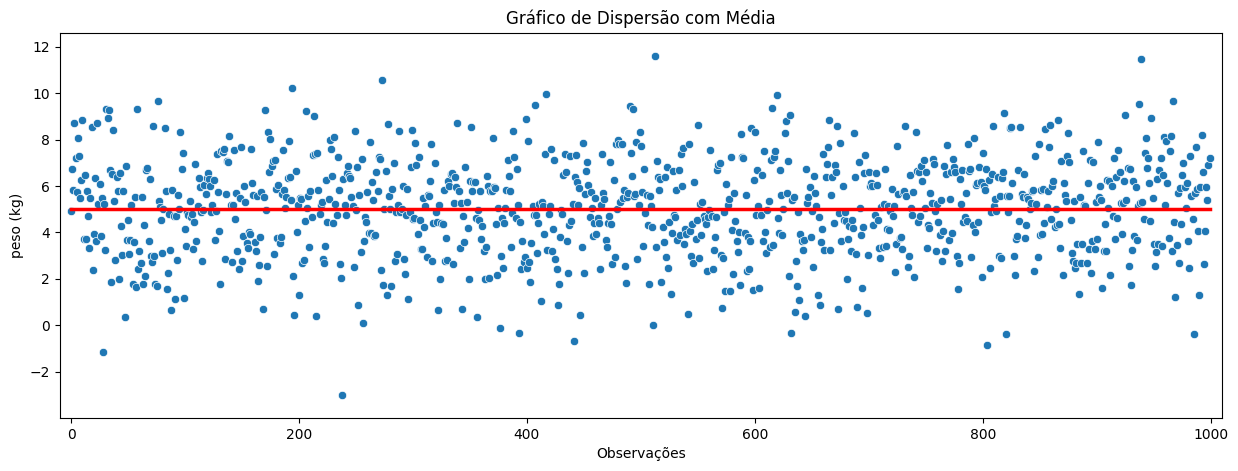

In [27]:
plt.rcParams['lines.linewidth'] = 2.5
fig, ax = plt.subplots(figsize=(15, 5))
# df_sample.plot.scatter(
#     x="index",
#     y=cont,
#     marker='*',
#     color='g',
#     s=1_000,
#     ax=ax
# )
# plt.plot(
#     df_sample_mean.index,
#     df_sample_mean.values,
#     color='g',
# )
sns.scatterplot(
    x='index',
    y=cont,
    data=df,
    ax=ax
)
plt.plot(
    df.index,
    [df[cont].mean() for _ in range(len(df.index))],
    color='r',
)
plt.title("Gráfico de Dispersão com Média")
plt.xlabel("Observações")
plt.ylabel(cont)
plt.xlim(-10, 1_010)
plt.ylim(df[cont].min()-1, df[cont].max()+1)
plt.show()

In [41]:
df[cont].shape

(1000,)

In [49]:
df[cont][:-1].sort_values().iloc[[
    498,
    499,
    500,
    501,
    502,
]]

890    5.14
414    5.15
936    5.16
810    5.16
247    5.16
Name: peso (kg), dtype: float64

In [44]:
df[cont][:-1].median()

5.15

In [40]:
df[cont][:-1].shape

(999,)

In [55]:
df[cont].sample(6, random_state=42).sort_values()

740    2.09
678    4.53
737    5.05
411    5.23
521    6.41
660    7.40
Name: peso (kg), dtype: float64

In [56]:
(5.23+5.05)/2

5.140000000000001

In [57]:
df[cont].sample(6, random_state=42).sort_values().median()

5.140000000000001

In [58]:
df[cont].mode()

0    5.05
1    5.17
2    5.55
3    5.78
Name: peso (kg), dtype: float64

In [76]:
df[cont].value_counts().head()

5.17    7
5.55    7
5.78    7
5.05    7
6.00    6
Name: peso (kg), dtype: int64

In [62]:
df[cont].sample(6, random_state=42).sort_values().mode()

0    2.09
1    4.53
2    5.05
3    5.23
4    6.41
5    7.40
Name: peso (kg), dtype: float64

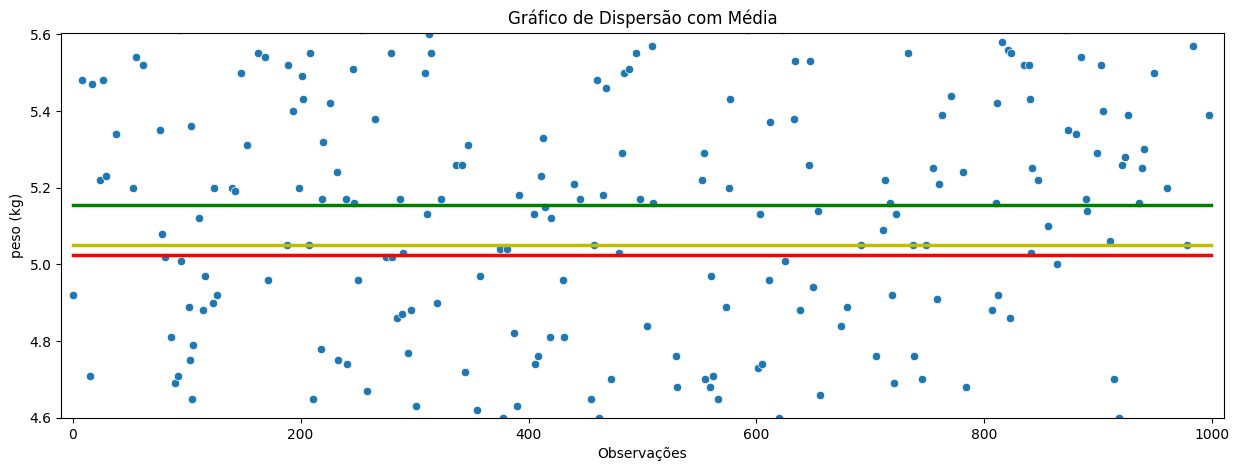

In [70]:
plt.rcParams['lines.linewidth'] = 2.5
fig, ax = plt.subplots(figsize=(15, 5))
# df_sample.plot.scatter(
#     x="index",
#     y=cont,
#     marker='*',
#     color='g',
#     s=1_000,
#     ax=ax
# )
# plt.plot(
#     df_sample_mean.index,
#     df_sample_mean.values,
#     color='g',
# )
sns.scatterplot(
    x='index',
    y=cont,
    data=df,
    ax=ax
)
plt.plot(
    df.index,
    [df[cont].mean() for _ in range(len(df.index))],
    color='r',
)
plt.plot(
    df.index,
    [df[cont].median() for _ in range(len(df.index))],
    color='g',
)
plt.plot(
    df.index,
    [df[cont].mode()[0] for _ in range(len(df.index))],
    color='y',
)
plt.title("Gráfico de Dispersão com Média")
plt.xlabel("Observações")
plt.ylabel(cont)
plt.xlim(-10, 1_010)
plt.ylim(df[cont].quantile(.4), df[cont].quantile(.6))
plt.show()

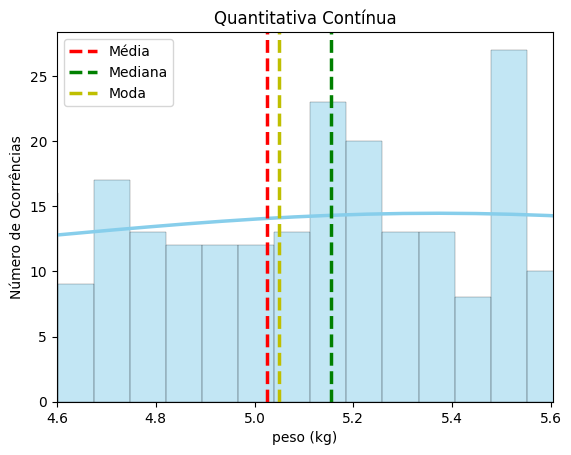

In [75]:
sns.histplot(
    x=cont,
    kde=True,
    bins=200,
    color='skyblue',
    data=df,
)

plt.xlim(df[cont].quantile(.4), df[cont].quantile(.6))

plt.axvline(df[cont].mean(), color='r', linestyle='--', label='Média')
plt.axvline(df[cont].median(), color='g', linestyle='--', label='Mediana')
plt.axvline(df[cont].mode()[0], color='y', linestyle='--', label='Moda')
plt.legend()
plt.title("Quantitativa Contínua")
plt.xlabel(cont)
plt.ylabel("Número de Ocorrências")
plt.show()